In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from google.colab import files
from mpl_toolkits.mplot3d import Axes3D


In [12]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
data = pd.read_csv(filename)

print("Dataset shape:", data.shape)
print(data.head())


Saving PCA_for_Image_Compression_mnist_test.csv to PCA_for_Image_Compression_mnist_test (1).csv
Dataset shape: (10000, 785)
   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      7    0    0    0    0    0    0    0    0    0  ...      0      0   
1      2    0    0    0    0    0    0    0    0    0  ...      0      0   
2      1    0    0    0    0    0    0    0    0    0  ...      0      0   
3      0    0    0    0    0    0    0    0    0    0  ...      0      0   
4      4    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]


In [13]:
X = data.select_dtypes(include=[np.number])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data shape after scaling:", X_scaled.shape)


Data shape after scaling: (10000, 785)


In [14]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)


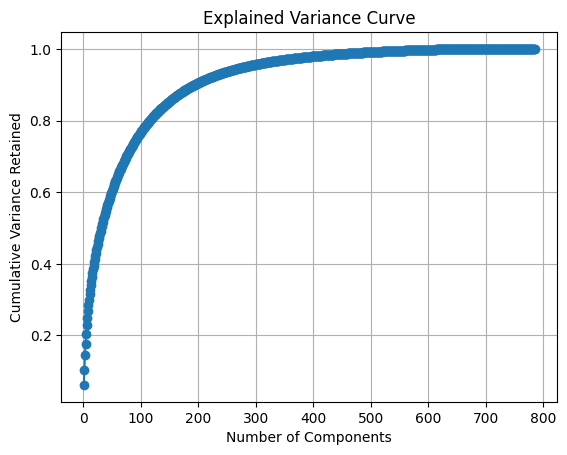

In [15]:
plt.plot(np.arange(1, len(explained_variance_ratio)+1), explained_variance_ratio, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Retained")
plt.title("Explained Variance Curve")
plt.grid(True)
plt.show()


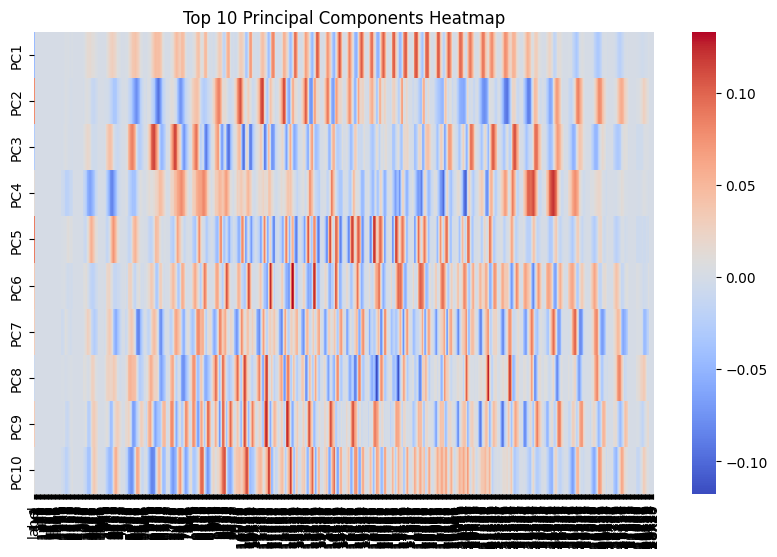

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(pca.components_[:10], cmap="coolwarm", annot=False,
            xticklabels=X.columns, yticklabels=[f"PC{i+1}" for i in range(10)])
plt.title("Top 10 Principal Components Heatmap")
plt.show()


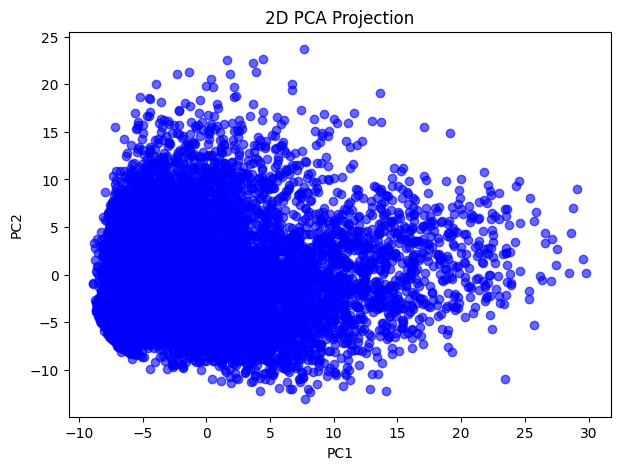

In [17]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], alpha=0.6, c='blue')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection")
plt.show()


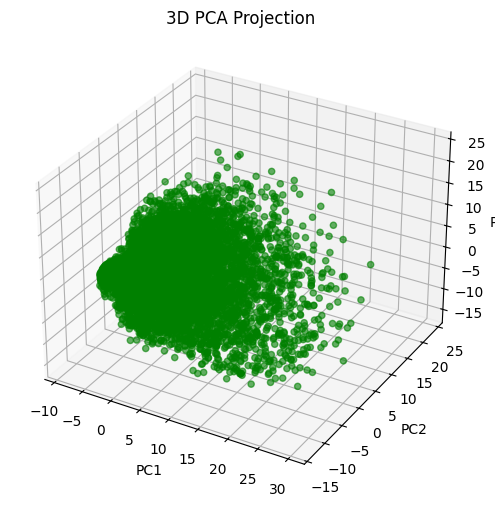

In [18]:
if X_scaled.shape[1] > 2:
    pca_3d = PCA(n_components=3)
    X_3d = pca_3d.fit_transform(X_scaled)

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(X_3d[:,0], X_3d[:,1], X_3d[:,2], alpha=0.6, c='green')
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title("3D PCA Projection")
    plt.show()


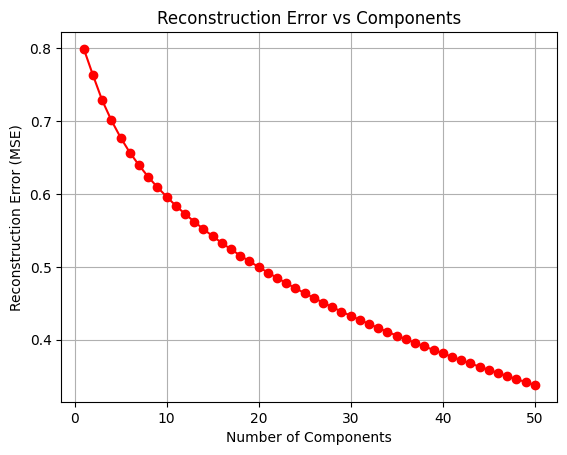

In [19]:
components_list = range(1, min(50, X_scaled.shape[1])+1)
errors = []

for n in components_list:
    pca_temp = PCA(n_components=n)
    X_transformed = pca_temp.fit_transform(X_scaled)
    X_reconstructed = pca_temp.inverse_transform(X_transformed)
    errors.append(mean_squared_error(X_scaled, X_reconstructed))

plt.plot(components_list, errors, marker='o', color='red')
plt.xlabel("Number of Components")
plt.ylabel("Reconstruction Error (MSE)")
plt.title("Reconstruction Error vs Components")
plt.grid(True)
plt.show()
